In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

from sv3.nn import FunctionalModelJac, MLP
from sv3.svd_sgd import SVDOptimizer

import sys
sys.path.append('..')
import copy
from pathlib import Path
import pandas as pd
import pickle

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: mps


In [2]:
LOADER_SEED = 51159
MODEL_SEED = 4372892
DATA_SEED = 54631
batch_size = 32
microbatch_sizes = [1,2,4,8,16,32]
K = 16
lr_svd = 0.1
n_epoch = 20
lr_standard = 1e-3
rtol = 1e-2
drop_last = True
mlp_kwargs = {
    "input_dim": 1,
    "hidden_dims": [16,16,16],
    "output_dim": 1
}
standard_optimizers = ['Adam','SGD','RMSprop']

In [3]:
from torchvision import datasets, transforms
from experiments.datasets import Toy1DRegressionDataset

toy_1d = Toy1DRegressionDataset(seed=DATA_SEED)
train_dataset = toy_1d.train_dataset
test_dataset = toy_1d.val_dataset

In [4]:
set_seed(MODEL_SEED)
mlp_base = MLP(**mlp_kwargs)
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

### load results from scan

In [5]:
# Load all experiment results and combine into single DataFrame
RESULTS_DIR = Path('../experiment_results/toy_1d_scan/')

all_dfs = []
file_pattern = '*.pkl'

for filepath in sorted(RESULTS_DIR.glob(file_pattern)):
    with open(filepath, 'rb') as f:
        df_temp = pickle.load(f)
    all_dfs.append(df_temp)
    print(f"Loaded {filepath.name}: {len(df_temp)} rows")

df = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal: {len(df)} experiment runs")
print(f"\nColumns: {df.columns.tolist()}")

df_svd = df[df['optimizer'] == 'SVD'].copy()
df_baseline = df[df['optimizer'] != 'SVD'].copy()

df_svd = df_svd[(df_svd['k'] == K) & (df_svd['lr'] == lr_svd) & (df_svd['batch_size'] == batch_size)]
df_baseline = df_baseline[df_baseline['batch_size'] == batch_size]

Loaded toy_1d_scan_results_bs128_df.pkl: 24 rows
Loaded toy_1d_scan_results_bs32_df.pkl: 24 rows
Loaded toy_1d_scan_results_bs64_df.pkl: 24 rows

Total: 72 experiment runs

Columns: ['batch_size', 'k_fraction', 'k', 'lr', 'losses', 'svd_info', 'optimizer']


### train w/o k fix

In [6]:
device = 'cpu'
model_svd = MLP(**mlp_kwargs)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    loss = (pred - y)**2
    loss = loss.sum(dim=-1)
    return loss

model_svd = FunctionalModelJac(model_svd, loss_fn, device=device)
optimizer = SVDOptimizer(model_svd,lr=lr_svd,k=K,rtol=rtol,track_svd_info=True,svd_mode='randomized',
                         use_k_fix=False)


train_loader = DataLoader(toy_1d.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED),drop_last=True)
test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

model_svd, losses_run, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info_preFix = optimizer.svd_info
losses_svd_preFix = losses_run

torch.compiler.reset()

100%|██████████| 20/20 [00:13<00:00,  1.49it/s]


### train w/ k fix

In [7]:
device = 'cpu'
model_svd = MLP(**mlp_kwargs)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    loss = (pred - y)**2
    loss = loss.sum(dim=-1)
    return loss

model_svd = FunctionalModelJac(model_svd, loss_fn, device=device)
optimizer = SVDOptimizer(model_svd,lr=lr_svd,k=K,rtol=rtol,track_svd_info=True,svd_mode='randomized',
                         use_k_fix=True)


train_loader = DataLoader(toy_1d.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED),drop_last=True)
test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

model_svd, losses_run, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info_postFix = optimizer.svd_info
losses_svd_postFix = losses_run

torch.compiler.reset()

100%|██████████| 20/20 [00:09<00:00,  2.18it/s]


### compare w and w/o k fix

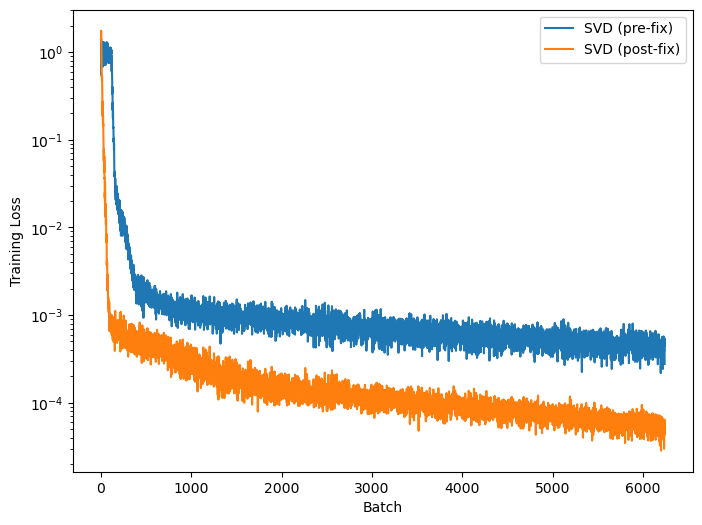

In [9]:
plt.figure(figsize=(8,6))
plt.plot(losses_svd_preFix['train_batch'], label='SVD (pre-fix)')
plt.plot(losses_svd_postFix['train_batch'], label='SVD (post-fix)')
plt.xlabel('Batch')
plt.ylabel('Training Loss')
plt.legend()
plt.yscale('log')

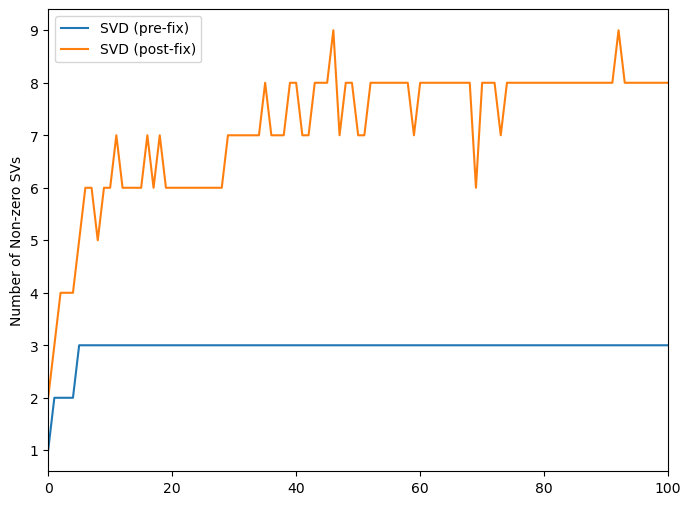

In [10]:
num_svs_prefix = svd_info_preFix['num_nonzero_svs']
num_svs_postfix = svd_info_postFix['num_nonzero_svs']
plt.figure(figsize=(8,6))
plt.plot(num_svs_prefix, label='SVD (pre-fix)')
plt.plot(num_svs_postfix, label='SVD (post-fix)')
plt.xlim(0,100)
plt.ylabel('Number of Non-zero SVs')
plt.legend()

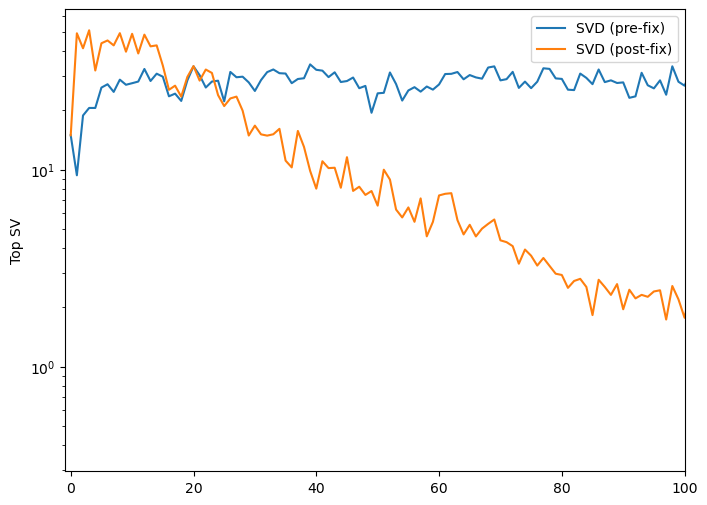

In [13]:
svs_prefix = svd_info_preFix['svs']
svs_postfix = svd_info_postFix['svs']
plt.figure(figsize=(8,6))
plt.plot([s[0] for s in svs_prefix], label='SVD (pre-fix)')
plt.plot([s[0] for s in svs_postfix], label='SVD (post-fix)')
plt.yscale('log')
plt.xlim(-1,100)
plt.ylabel('Top SV')
plt.legend()

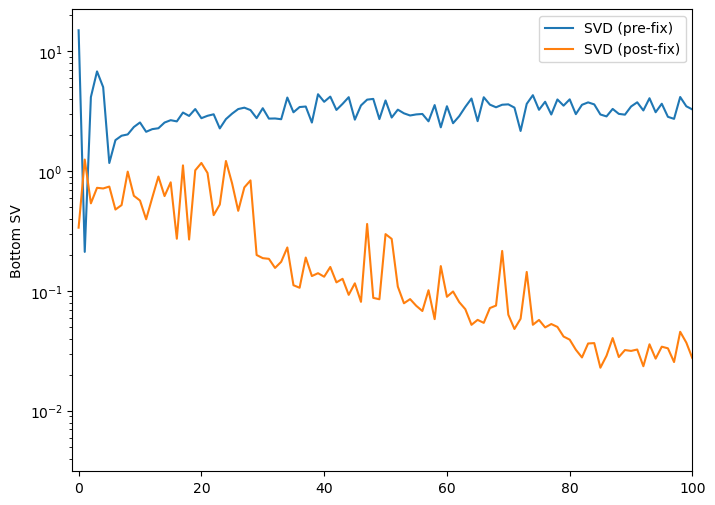

In [14]:
svs_prefix = svd_info_preFix['svs']
svs_postfix = svd_info_postFix['svs']
plt.figure(figsize=(8,6))
plt.plot([s[-1] for s in svs_prefix], label='SVD (pre-fix)')
plt.plot([s[-1] for s in svs_postfix], label='SVD (post-fix)')
plt.yscale('log')
plt.xlim(-1,100)
plt.ylabel('Bottom SV')
plt.legend()

### Compare

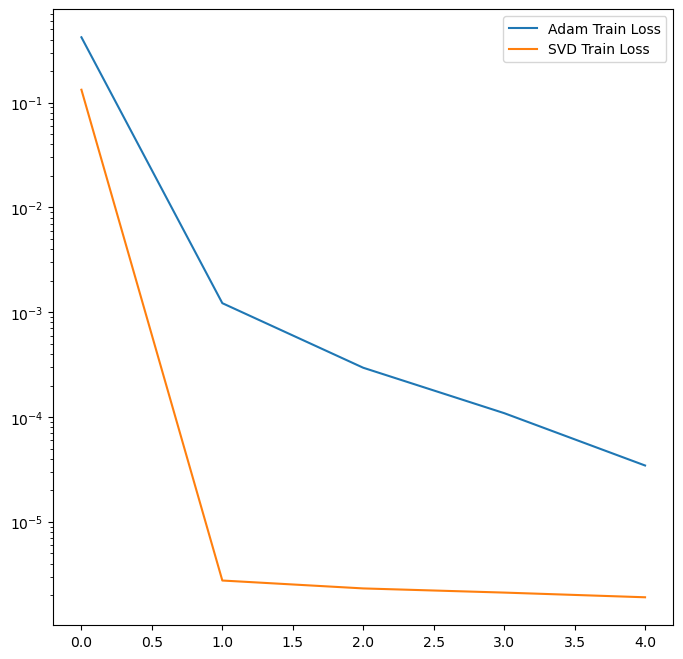

In [121]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['train'])), losses_adam['train'], label='Adam Train Loss')
ax.plot(np.arange(len(losses_svd['train'])), losses_svd['train'], label=f'SVD Train Loss')
plt.yscale('log')
plt.legend()

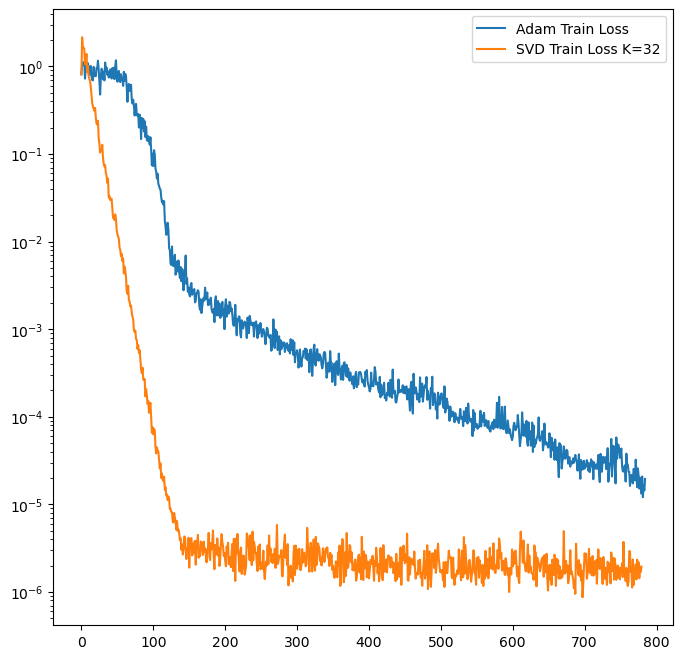

In [122]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['train_batch'])), losses_adam['train_batch'], label='Adam Train Loss')
ax.plot(np.arange(len(losses_svd['train_batch'])), losses_svd['train_batch'], label=f'SVD Train Loss K={K}')
plt.yscale('log')
plt.legend()

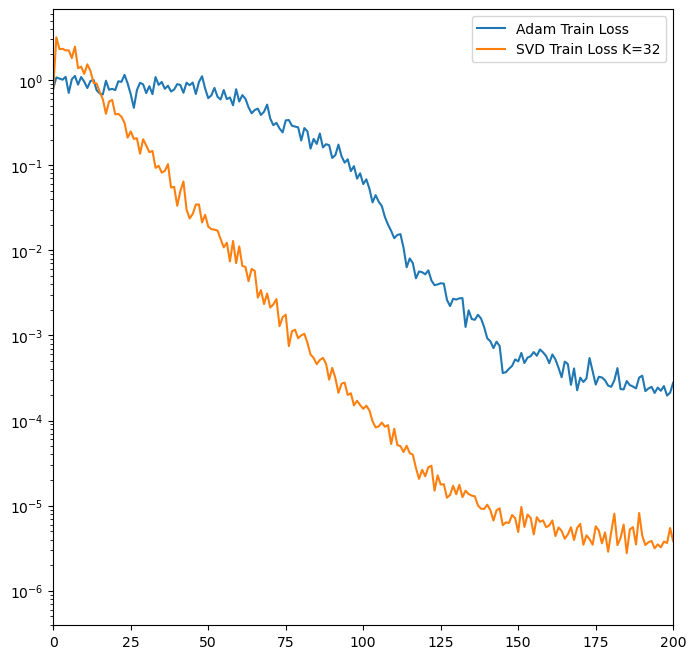

In [95]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['train_batch'])), losses_adam['train_batch'], label='Adam Train Loss')
ax.plot(np.arange(len(losses_svd['train_batch'])), losses_svd['train_batch'], label=f'SVD Train Loss K={K}')
plt.yscale('log')
ax.set_xlim(0,200)
plt.legend()

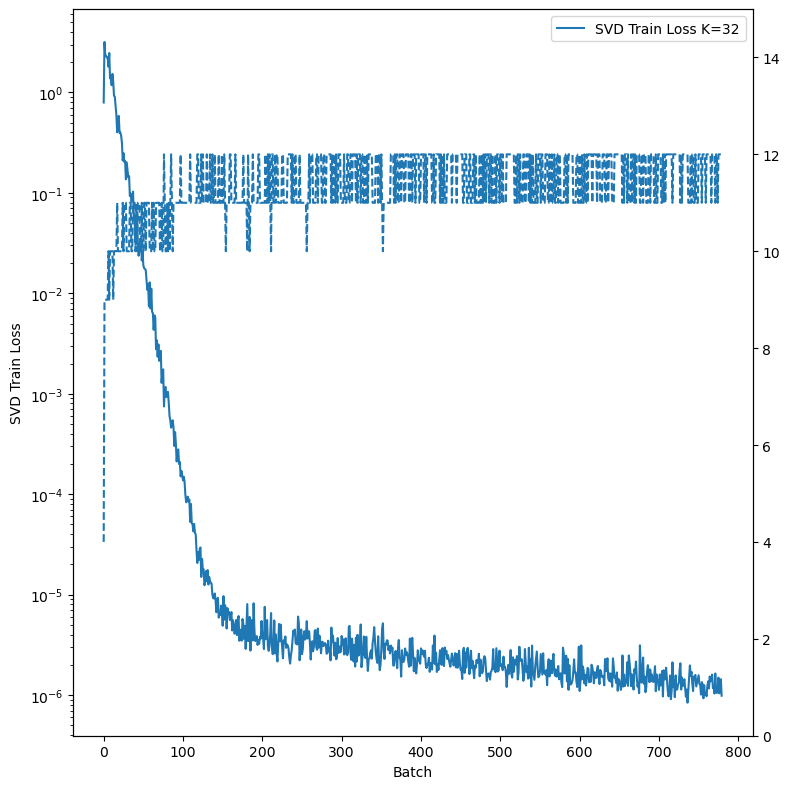

In [96]:
fig, ax1 = plt.subplots(figsize=(8,8))

plots = []
p1 = ax1.plot(np.arange(len(losses_svd['train_batch'])), losses_svd['train_batch'], f'C0-', label=f'SVD Train Loss K={K}')
plots.append(p1[0])
ax1.set_xlabel('Batch')
ax1.set_ylabel('SVD Train Loss')
ax1.set_yscale('log')
ax1.legend()

ax2 = ax1.twinx()
p2 = ax2.plot(np.arange(len(svd_info['num_nonzero_svs'])), svd_info['num_nonzero_svs'], f'C0--',label=f'Number of Nonzero SVs K={K}')
ax2.set_ylim(0,15)

ax1.legend(handles=plots,ncol=2)
plt.tight_layout()